# Matched-pair recall-gap test using fine-grained features (CUB-200-2011)

We want to measure whether an attribute probe is truly using visual evidence for the attribute,
or whether it is partially relying on species identity as a shortcut.

Core idea:
For a given attribute and a pair of species (S1, S2), we build a matched test set where
attribute prevalence is identical in both species:
- same number of positive examples in S1 and S2
- same number of negative examples in S1 and S2

Then we evaluate:
- recall on positives for S1
- recall on positives for S2
- the recall gap |recall(S1) - recall(S2)|

If the recall gap is consistently large even after perfect prevalence matching,
that suggests the probe is using species-specific cues, not just attribute evidence.

We run this across:
- many attributes
- many species pairs
- multiple random seeds (because subsampling is random)
and summarize the recall gaps.


For each attribute:

1. Train a linear probe on top of frozen visual features.
2. Evaluate the probe on held-out test images.
3. Group test images by species.
4. For pairs of species:
   - Subsample images so that both species have the same number of
     attribute-positive and attribute-negative examples.
   - Compute recall on attribute-positive images for each species.
5. Measure the recall gap between species.

In [1]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn


In [2]:
ROOT = Path("/scratch/network/cr7998/cv_emergence_project")
CUB  = ROOT / "data" / "CUB_200_2011"

ATTR_TXT = ROOT / "data" / "attributes.txt"   # attr_id -> attr_name like has_primary_color::yellow

BASE_FEAT = ROOT / "features" / "resnet50_cub_fine"
CBM_FEAT  = ROOT / "features" / "resnet50_cub_cbm_fine"

assert CUB.exists(), f"Missing CUB folder: {CUB}"
assert ATTR_TXT.exists(), f"Missing attributes.txt: {ATTR_TXT}"
assert BASE_FEAT.exists(), f"Missing baseline fine features: {BASE_FEAT}"
assert CBM_FEAT.exists(), f"Missing cbm fine features: {CBM_FEAT}"

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

In [3]:
def load_species_maps(cub_root: Path):
    """
    Loads species ID to name mappings from classes.txt.
    Also produces a prettified version for printing.
    """
    classes = pd.read_csv(
        cub_root / "classes.txt",
        sep=r"\s+",
        header=None,
        names=["species_id", "class_name"],
        engine="python"
    )

    def pretty(name: str) -> str:
        # Example: "001.Black_footed_Albatross" -> "Black footed albatross"
        return name.split(".", 1)[-1].replace("_", " ")

    return dict(zip(
        classes["species_id"].astype(int),
        classes["class_name"].map(pretty),
    ))

species_id_to_name = load_species_maps(CUB)

def spname(sid: int) -> str:
    return species_id_to_name.get(int(sid), f"species_{sid}")


In [4]:
def load_meta(cub_root: Path) -> pd.DataFrame:
    """
    Returns a dataframe mapping each image to:
    - species ID
    - train/test split
    """
    img_species = pd.read_csv(
        cub_root / "image_class_labels.txt",
        sep=r"\s+",
        header=None,
        names=["image_id", "species_id"],
        engine="python"
    )

    split_df = pd.read_csv(
        cub_root / "train_test_split.txt",
        sep=r"\s+",
        header=None,
        names=["image_id", "is_train"],
        engine="python"
    )

    meta = img_species.merge(split_df, on="image_id")
    meta["species_name"] = meta["species_id"].map(spname)
    return meta

meta = load_meta(CUB)


In [5]:
def load_image_attr_labels_robust(cub_root: Path) -> pd.DataFrame:
    path = cub_root / "attributes" / "image_attribute_labels.txt"
    rows = []
    bad = 0

    with open(path, "r") as f:
        for line in f:
            toks = line.strip().split()
            if len(toks) < 4:
                bad += 1
                continue
            try:
                image_id = int(toks[0])
                attr_id  = int(toks[1])
                is_pres  = int(toks[2])
                cert     = int(toks[3])
                rows.append((image_id, attr_id, is_pres, cert))
            except:
                bad += 1

    df = pd.DataFrame(rows, columns=["image_id", "attr_id", "is_present", "certainty"])
    print("Parsed rows:", len(df), "bad lines skipped:", bad)
    return df

img_attr_long = load_image_attr_labels_robust(CUB)
img_attr_long.head()


Parsed rows: 3677856 bad lines skipped: 0


,image_id,attr_id,is_present,certainty
0,1,1,0,3
1,1,2,0,3
2,1,3,0,3
3,1,4,0,3
4,1,5,1,3


In [6]:
def load_attr_maps(attr_txt: Path):
    rows = []
    with open(attr_txt, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            aid_str, name = line.split(" ", 1)
            rows.append((int(aid_str), name))
    df = pd.DataFrame(rows, columns=["attr_id", "attr_name"])
    name_to_id = dict(zip(df["attr_name"], df["attr_id"]))
    id_to_name = dict(zip(df["attr_id"], df["attr_name"]))
    return df, name_to_id, id_to_name

attr_df, attr_name_to_id, attr_id_to_name = load_attr_maps(ATTR_TXT)
attr_df.head()


,attr_id,attr_name
0,1,has_bill_shape::curved_(up_or_down)
1,2,has_bill_shape::dagger
2,3,has_bill_shape::hooked
3,4,has_bill_shape::needle
4,5,has_bill_shape::hooked_seabird


In [7]:
ATTR_LIST = [
    "has_primary_color::yellow",
    "has_throat_color::yellow",
    "has_underparts_color::yellow",
    "has_belly_color::yellow",
    "has_breast_color::yellow",
]
for a in ATTR_LIST:
    assert a in attr_name_to_id, f"Missing attribute in attributes.txt: {a}"


In [8]:
# What this cell does:
# - For a given attribute_id, merges:
#   meta (image->species, split) with attribute labels (image->y)
# - Produces a clean table with y in {0,1}. where y is whether the attribut below is present or not.
# Why it matters:
# - This is the ground-truth label table used for training and evaluation.

def build_attr_labeled_df(meta: pd.DataFrame,
                          img_attr_long: pd.DataFrame,
                          attr_id: int,
                          min_certainty: int = 1) -> pd.DataFrame:
    """
    Returns dataframe with:
      image_id, species_id, species_name, is_train, y, certainty
    Only keeps annotations with certainty >= min_certainty.
    """
    sub = img_attr_long[img_attr_long["attr_id"] == int(attr_id)].copy()
    sub = sub[sub["certainty"] >= int(min_certainty)].copy()

    out = meta.merge(sub[["image_id", "is_present", "certainty"]], on="image_id", how="inner")
    out = out.rename(columns={"is_present": "y"})
    out["y"] = out["y"].astype(int)
    return out[["image_id", "species_id", "species_name", "is_train", "y", "certainty"]]

print("Defined:", "build_attr_labeled_df")

# sanity check on one attribute
attr_name = "has_primary_color::yellow"
aid = attr_name_to_id[attr_name]
lab = build_attr_labeled_df(meta, img_attr_long, aid, min_certainty=1)
print("Attribute:", attr_name, "rows labeled:", len(lab), "pos rate:", lab.y.mean())
lab.head()


Defined: build_attr_labeled_df
Attribute: has_primary_color::yellow rows labeled: 11788 pos rate: 0.1506616898540889


,image_id,species_id,species_name,is_train,y,certainty
0,1,1,Black footed Albatross,0,0,3
1,2,1,Black footed Albatross,1,0,4
2,3,1,Black footed Albatross,0,0,4
3,4,1,Black footed Albatross,1,0,4
4,5,1,Black footed Albatross,1,0,4


In [9]:
# - Loads a feature tensor from disk and converts it to float32 torch.Tensor.

def safe_torch_load(path: Path):
    """
    Uses weights_only=True if supported to reduce pickle risk warnings.
    """
    try:
        return torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(path, map_location="cpu")

def load_features(feat_dir: Path, layer: str, split: str) -> torch.Tensor:
    """
    Loads feature tensor saved as {layer}_{split}.pt from feat_dir.
    """
    p = feat_dir / f"{layer}_{split}.pt"
    assert p.exists(), f"Missing: {p}"
    X = safe_torch_load(p)
    if not isinstance(X, torch.Tensor):
        X = torch.tensor(X)
    return X.float()

In [10]:
import numpy as np
import torch

def to_1d_int_array(x):
    """Convert tensor/list/np array to 1D int numpy array."""
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    x = np.array(x)
    x = x.reshape(-1)
    return x.astype(int)

def load_split_order(feat_dir, split):
    p = feat_dir / f"labels_{split}.pt"
    assert p.exists(), f"Missing: {p}"
    t = torch.load(p, map_location="cpu", weights_only=True)

    assert isinstance(t, dict), f"Expected dict in {p}, got {type(t)}"
    assert "image_ids" in t, f"{p} missing 'image_ids' key; has {list(t.keys())}"

    ids = to_1d_int_array(t["image_ids"])
    kind = infer_kind(ids)
    return kind, ids


def infer_kind(arr):
    # Heuristic:
    # - species ids: 1..200 (sometimes 0..199)
    # - image ids: 1..11788
    if arr.max() <= 200 and arr.min() >= 0:
        return "species_id_like"
    if arr.max() > 200:
        return "image_id_like"
    return "unknown"


In [11]:
LAYER = "layer4.0"

base_kind_tr, base_ids_tr = load_split_order(BASE_FEAT, "train")
base_kind_te, base_ids_te = load_split_order(BASE_FEAT, "test")
cbm_kind_tr,  cbm_ids_tr  = load_split_order(CBM_FEAT, "train")
cbm_kind_te,  cbm_ids_te  = load_split_order(CBM_FEAT, "test")

print(
    "Baseline train:",
    base_kind_tr,
    "id range:",
    (base_ids_tr.min(), base_ids_tr.max())
)

print(
    "Baseline test:",
    base_kind_te,
    "id range:",
    (base_ids_te.min(), base_ids_te.max())
)

Baseline train: image_id_like id range: (2, 11787)
Baseline test: image_id_like id range: (1, 11788)


In [12]:
# What this cell does:
# - Aligns features (in feature row order) to attribute labels by image_id.
# - Produces X_aligned and df_aligned with the same ordering.


def align_features_and_labels(X_split: torch.Tensor,
                              image_ids_in_feature_order: np.ndarray,
                              labeled_df_split: pd.DataFrame):
    """
    Inputs:
      X_split: feature tensor of shape [N, D]
      image_ids_in_feature_order: length N, image_id for each row of X_split
      labeled_df_split: dataframe with at least columns [image_id, y, species_id, species_name]

    Output:
      X_aligned: features for images that have labels
      df_aligned: same rows, same order, includes y and species info
    """
    labeled = labeled_df_split.set_index("image_id")[["y", "species_id", "species_name"]]

    keep_idx = []
    rows = []
    for i, img_id in enumerate(image_ids_in_feature_order):
        img_id = int(img_id)
        if img_id in labeled.index:
            keep_idx.append(i)
            y, sid, sname = labeled.loc[img_id]
            rows.append((img_id, int(sid), str(sname), int(y)))

    X_aligned = X_split[keep_idx]
    df_aligned = pd.DataFrame(rows, columns=["image_id", "species_id", "species_name", "y"])
    return X_aligned, df_aligned

In [13]:
# What this cell does:
# - Defines a linear probe (single linear layer).
# - Trains it using BCEWithLogitsLoss with mild class-imbalance handling.
# Why it matters:
# - Probe is the measurement instrument for "is the attribute encoded in features?"

class LinearProbe(nn.Module):
    def __init__(self, d: int):
        super().__init__()
        self.lin = nn.Linear(d, 1)

    def forward(self, x):
        return self.lin(x).squeeze(-1)

def train_probe(Xtr: torch.Tensor, ytr: np.ndarray,
                seed=0, lr=1e-2, wd=1e-4, epochs=25, batch=512):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    Xtr = Xtr.to(device)
    ytr_t = torch.tensor(ytr, dtype=torch.float32, device=device)

    probe = LinearProbe(Xtr.shape[1]).to(device)
    opt = torch.optim.AdamW(probe.parameters(), lr=lr, weight_decay=wd)

    pos = float(ytr_t.mean().item())
    pos_weight = torch.tensor([(1 - pos) / pos], device=device) if 0 < pos < 1 else torch.tensor([1.0], device=device)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    n = Xtr.shape[0]
    for _ in range(epochs):
        perm = torch.randperm(n, device=device)
        for i in range(0, n, batch):
            idx = perm[i:i+batch]
            logits = probe(Xtr[idx])
            loss = loss_fn(logits, ytr_t[idx])
            opt.zero_grad()
            loss.backward()
            opt.step()

    return probe

@torch.no_grad()
def predict_probs(probe: nn.Module, X: torch.Tensor, batch=4096) -> np.ndarray:
    probe.eval()
    probs = []
    for i in range(0, X.shape[0], batch):
        xb = X[i:i+batch].to(device)
        logits = probe(xb)
        probs.append(torch.sigmoid(logits).detach().cpu())
    return torch.cat(probs, dim=0).numpy()

print("Defined:", "LinearProbe", "train_probe", "predict_probs")


Defined: LinearProbe train_probe predict_probs


1. Identify species that have both positive and negative examples.
2. For each pair:
   - Subsample so both species have identical numbers of positives and negatives.
3. Compute recall on positive examples for each species.
4. Measure the absolute recall difference.

In [14]:
# What this cell does:
# - Finds species that have enough positives and negatives for the chosen attribute.
# - Samples many species pairs.
# - For each pair, subsamples to match prevalence exactly and computes recall on positives.
# Why it matters:
# - This isolates species-specific differences even when prevalence is controlled perfectly.

def make_candidate_pairs(df_test: pd.DataFrame, min_each=10, max_pairs=200, seed=0):
    """
    Returns list of tuples (sid_A, sid_B, mpos, mneg) where:
      mpos = min(posA, posB)
      mneg = min(negA, negB)
    and both are >= min_each.
    """
    g = df_test.groupby("species_id")["y"].agg(["count", "sum"]).rename(columns={"sum": "pos"})
    g["neg"] = g["count"] - g["pos"]
    ok = g[(g["pos"] >= min_each) & (g["neg"] >= min_each)]
    sids = ok.index.to_list()

    rng = np.random.default_rng(seed)
    pairs = []
    if len(sids) < 2:
        return pairs

    for _ in range(max_pairs * 10):
        a, b = rng.choice(sids, size=2, replace=False)
        mpos = int(min(ok.loc[a, "pos"], ok.loc[b, "pos"]))
        mneg = int(min(ok.loc[a, "neg"], ok.loc[b, "neg"]))
        if mpos >= min_each and mneg >= min_each:
            pairs.append((int(a), int(b), mpos, mneg))
        if len(pairs) >= max_pairs:
            break
    return pairs

def matched_pair_eval(df_test: pd.DataFrame, probs: np.ndarray, sid_A: int, sid_B: int,
                      mpos: int, mneg: int, seed=0, thr=0.5):
    """
    Subsamples to:
      mpos positives + mneg negatives from each species.
    Computes recall on positive examples only for each species subset.
    """
    df = df_test.copy()
    df["prob"] = probs

    A = df[df.species_id == sid_A]
    B = df[df.species_id == sid_B]

    A_pos, A_neg = A[A.y == 1], A[A.y == 0]
    B_pos, B_neg = B[B.y == 1], B[B.y == 0]

    A_s = pd.concat([A_pos.sample(mpos, random_state=seed), A_neg.sample(mneg, random_state=seed)])
    B_s = pd.concat([B_pos.sample(mpos, random_state=seed), B_neg.sample(mneg, random_state=seed)])

    def recall_pos(d):
        pos = d[d.y == 1]
        pred = (pos.prob.values >= thr).astype(int)
        return float((pred == 1).mean()) if len(pos) else np.nan

    recA = recall_pos(A_s)
    recB = recall_pos(B_s)

    return {
        "sid_A": sid_A,
        "sid_B": sid_B,
        "species_A": spname(sid_A),
        "species_B": spname(sid_B),
        "npos": int(mpos),
        "nneg": int(mneg),
        "recall_A": float(recA),
        "recall_B": float(recB),
        "gap": float(abs(recA - recB)),
    }

def eval_pair_vectorized(probs, y_arr, sid_arr, sid_A, sid_B,
                          mpos, mneg, n_seeds, seed=0, thr=0.5):
    """
    Bootstrap statistics for one species pair across ALL seeds at once.
    Binary recall: fraction of positives predicted >= thr.
    No pandas — pure numpy.
    """
    rng = np.random.default_rng(seed)
    A_pos = np.where((sid_arr == sid_A) & (y_arr == 1))[0]
    B_pos = np.where((sid_arr == sid_B) & (y_arr == 1))[0]
    # (n_seeds, mpos) sample index matrices
    iAp = rng.integers(len(A_pos), size=(n_seeds, mpos))
    iBp = rng.integers(len(B_pos), size=(n_seeds, mpos))
    pred_bin = (np.asarray(probs) >= thr).astype(np.int8)
    recA = pred_bin[A_pos[iAp]].mean(axis=1)   # (n_seeds,)
    recB = pred_bin[B_pos[iBp]].mean(axis=1)   # (n_seeds,)
    gaps  = np.abs(recA - recB)
    sgaps = recA - recB
    EPS   = 1e-12
    return {
        "sid_A": int(sid_A), "sid_B": int(sid_B),
        "species_A": spname(sid_A), "species_B": spname(sid_B),
        "npos": int(mpos), "nneg": int(mneg),
        "gap_mean":  float(gaps.mean()),
        "gap_std":   float(gaps.std()),
        "gap_ci_lo": float(np.quantile(gaps, 0.025)),
        "gap_ci_hi": float(np.quantile(gaps, 0.975)),
        "gap_p": float(2.0 * min(float(np.mean(sgaps <= 0)),
                                  float(np.mean(sgaps >= 0)))),
        "gap_snr":  float(gaps.mean() / (gaps.std() + EPS)),
        "gap_norm": float(gaps.mean()),
        "n_runs":   n_seeds,
    }


def matched_pair_bootstrap_summary(
    df_te: pd.DataFrame,
    probs: np.ndarray,
    pairs,
    *,
    thr=0.5,
    B=300,
):
    """
    For each candidate (sid_A, sid_B, mpos, mneg), runs eval_pair_vectorized
    (B bootstrap resamples in one numpy call). Returns (empty_df, pair_summary).
    """
    if not pairs:
        return pd.DataFrame(), pd.DataFrame()

    y_arr   = df_te["y"].to_numpy(dtype=int)
    sid_arr = df_te["species_id"].to_numpy()
    rows = [
        eval_pair_vectorized(probs, y_arr, sid_arr, a, b, mpos, mneg,
                             n_seeds=B, seed=i, thr=thr)
        for i, (a, b, mpos, mneg) in enumerate(pairs)
    ]
    pair_summary = pd.DataFrame(rows)
    pair_summary["gap_ci_width"] = pair_summary["gap_ci_hi"] - pair_summary["gap_ci_lo"]
    return pd.DataFrame(), pair_summary.sort_values("gap_mean", ascending=False).reset_index(drop=True)

def species_recall_prevalence_table(df_te: pd.DataFrame, probs: np.ndarray, thr=0.5) -> pd.DataFrame:
    """
    Per-species table on the TEST set:
      - n, n_pos, n_neg
      - prevalence = n_pos / n
      - tp = # of positives predicted positive
      - recall = tp / n_pos
      - precision = tp / n_pred_pos   (optional but cheap and often useful)
    """
    df = df_te[["species_id", "species_name", "y"]].copy()
    df["prob"] = np.asarray(probs, dtype=float)
    df["pred"] = (df["prob"] >= thr).astype(int)

    # Basic counts per species
    g = (df.groupby(["species_id", "species_name"], as_index=False)
           .agg(
               n=("y", "size"),
               n_pos=("y", "sum"),
               n_pred_pos=("pred", "sum"),
           ))
    g["n_neg"] = g["n"] - g["n_pos"]
    g["prevalence"] = g["n_pos"] / g["n"]

    # True positives per species (only among y==1)
    tp = (df[df["y"] == 1]
            .groupby(["species_id", "species_name"])["pred"]
            .sum()
            .reset_index(name="tp"))

    out = g.merge(tp, on=["species_id", "species_name"], how="left")
    out["tp"] = out["tp"].fillna(0).astype(int)

    # Recall: tp / n_pos (handle n_pos==0)
    out["recall"] = np.where(out["n_pos"] > 0, out["tp"] / out["n_pos"], np.nan)

    # Precision: tp / n_pred_pos (handle n_pred_pos==0)
    out["precision"] = np.where(out["n_pred_pos"] > 0, out["tp"] / out["n_pred_pos"], np.nan)

    out = out.sort_values(["n"], ascending=False).reset_index(drop=True)
    return out


def add_species_bootstrap_ci(df_te: pd.DataFrame, probs: np.ndarray, thr=0.5, B=300, min_pos_for_ci=1) -> pd.DataFrame:
    """
    Per-species bootstrap CI for recall. Vectorised: samples all B bootstraps at once
    per species using numpy integer indexing — no pandas in the inner loop.
    """
    base  = species_recall_prevalence_table(df_te, probs, thr=thr)
    y_arr = df_te["y"].to_numpy(dtype=int)
    p_arr = np.asarray(probs, dtype=float)
    rng   = np.random.default_rng(0)

    ci_rows = []
    for (sid, sname), grp in df_te.groupby(["species_id", "species_name"]):
        idx   = grp.index.to_numpy()
        y_s   = y_arr[idx];  p_s = p_arr[idx];  n = len(idx)
        n_pos = int(y_s.sum())

        if n_pos < min_pos_for_ci:
            ci_rows.append({"species_id": int(sid), "species_name": str(sname),
                            "recall_bs_mean": np.nan, "recall_ci_lo": np.nan,
                            "recall_ci_hi": np.nan, "recall_ci_width": np.nan, "B": B})
            continue

        # All B bootstraps at once: (B, n) index array
        boot_idx  = rng.integers(0, n, size=(B, n))
        y_boot    = y_s[boot_idx]               # (B, n)
        p_boot    = p_s[boot_idx]               # (B, n)
        pos_mask  = (y_boot == 1)
        pred_mask = (p_boot >= thr)
        n_pos_bt  = pos_mask.sum(axis=1)        # (B,)
        tp_bt     = (pos_mask & pred_mask).sum(axis=1)  # (B,)
        with np.errstate(invalid="ignore"):
            recalls = np.where(n_pos_bt > 0, tp_bt / n_pos_bt, np.nan)
        lo, hi = bootstrap_ci(recalls)
        ci_rows.append({"species_id": int(sid), "species_name": str(sname),
                        "recall_bs_mean": float(np.nanmean(recalls)),
                        "recall_ci_lo": lo, "recall_ci_hi": hi,
                        "recall_ci_width": (hi - lo) if np.isfinite(lo) and np.isfinite(hi) else np.nan,
                        "B": B})

    return base.merge(pd.DataFrame(ci_rows), on=["species_id", "species_name"], how="left")

In [15]:
import numpy as np

def bootstrap_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    return (float(np.quantile(x, alpha/2)),
            float(np.quantile(x, 1 - alpha/2)))

def bootstrap_p_value(x):
    x = np.asarray(x, dtype=float)
    p_lo = float(np.mean(x <= 0))
    p_hi = float(np.mean(x >= 0))
    return 2.0 * min(p_lo, p_hi)


In [16]:
def bootstrap_ci(x, alpha=0.05):
    """
    Percentile bootstrap CI for a 1D array x.
    Returns (lo, hi). If x is empty or all-nan, returns (nan, nan).
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if x.size == 0:
        return (np.nan, np.nan)
    lo = np.quantile(x, alpha/2)
    hi = np.quantile(x, 1 - alpha/2)
    return (float(lo), float(hi))

def bootstrap_p_value(values, null=0.0):
    """
    Two-sided bootstrap p-value for H0: E[value] == null
    Using bootstrap distribution of the statistic itself.

    p = 2 * min(P(value <= null), P(value >= null))
    """
    v = np.asarray(values, dtype=float)
    v = v[~np.isnan(v)]
    if v.size == 0:
        return np.nan
    p_lo = np.mean(v <= null)
    p_hi = np.mean(v >= null)
    return float(2.0 * min(p_lo, p_hi))

def safe_div(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    out = np.full_like(a, np.nan, dtype=float)
    m = b != 0
    out[m] = a[m] / b[m]
    return out


In [17]:
def run_one_attribute(
    attr_name: str,
    feat_dir: Path,
    split_order_kind_train: str,
    split_order_train: np.ndarray,
    split_order_kind_test: str,
    split_order_test: np.ndarray,
    layer: str,
    *,
    min_certainty: int = 1,
    thr: float = 0.5,
    epochs: int = 25,
    min_each: int = 10,
    n_pairs: int = 200,
    B_gap: int = 100,
    B_species: int = 100,
):
    """
    Runs the full pipeline for ONE attribute and ONE model's features:
      1) Build labeled train/test sets for this attribute (certainty filtering)
      2) Load train/test features for the chosen layer
      3) Align features to labels by image_id using split order arrays
      4) Train a linear probe on train features
      5) Predict probabilities on test features
      6) Build per-species prevalence+recall table (and bootstrap CI for recall)
      7) (Optional) Generate candidate species pairs for matched evaluation
      8) (Optional) Bootstrap matched-pair recall gap per pair (CI + p-value + stability metrics)
    """

    # Alignment requires feature order indexed by image_id.
    assert split_order_kind_train == "image_id_like" and split_order_kind_test == "image_id_like", (
        "Cannot align features to attribute labels because labels_{split}.pt is not image_id-like.\n"
        "If you hit this, we need to read the dataset ordering from your extractor code."
    )

    # Build per-image labels for this attribute.
    aid = attr_name_to_id[attr_name]
    lab = build_attr_labeled_df(meta, img_attr_long, aid, min_certainty=min_certainty)
    lab_train = lab[lab["is_train"] == 1].copy()
    lab_test  = lab[lab["is_train"] == 0].copy()

    # Load precomputed features.
    Xtr_all = load_features(feat_dir, layer, "train")
    Xte_all = load_features(feat_dir, layer, "test")

    # Align labeled images to feature tensor order.
    Xtr, df_tr = align_features_and_labels(Xtr_all, split_order_train, lab_train)
    Xte, df_te = align_features_and_labels(Xte_all, split_order_test,  lab_test)

    ytr = df_tr["y"].astype(int).to_numpy()
    yte = df_te["y"].astype(int).to_numpy()

    # Train probe + predict probabilities on test.
    probe = train_probe(Xtr, ytr, seed=0, epochs=epochs)
    probs = predict_probs(probe, Xte)

    # Species table (point estimates + bootstrap CI).
    species_table = add_species_bootstrap_ci(df_te, probs, thr=thr, B=B_species)

    # Overall accuracy at threshold (headline only; prof cares more about per-species table).
    test_acc = float(((probs >= thr).astype(int) == yte).mean()) if len(yte) else np.nan

    # Matched pairs (optional).
    if n_pairs is None or int(n_pairs) <= 0:
        res_long = pd.DataFrame()
        pair_summary = pd.DataFrame()
        pairs = []
    else:
        pairs = make_candidate_pairs(df_te, min_each=min_each, max_pairs=n_pairs, seed=0)
        res_long, pair_summary = matched_pair_bootstrap_summary(
            df_te, probs, pairs, thr=thr, B=B_gap
        )

    mean_gap = float(pair_summary["gap_mean"].mean()) if (pair_summary is not None and len(pair_summary)) else np.nan
    p90_gap  = float(pair_summary["gap_mean"].quantile(0.9)) if (pair_summary is not None and len(pair_summary)) else np.nan

    info = {
        "attr": attr_name,
        "layer": layer,
        "n_train": int(len(df_tr)),
        "n_test": int(len(df_te)),
        "train_pos_rate": float(ytr.mean()) if len(ytr) else np.nan,
        "test_pos_rate": float(yte.mean()) if len(yte) else np.nan,
        "test_acc": float(test_acc),
        "thr": float(thr),
        "epochs": int(epochs),
        "n_pairs": int(len(pairs)),
        "B_gap": int(B_gap),
        "B_species": int(B_species),
        "mean_gap": mean_gap,
        "p90_gap": p90_gap,
    }

    return info, res_long, pair_summary, df_te, species_table


In [18]:
def screen_attributes_for_species_variation(
    candidate_attrs,
    feat_dir: Path,
    kind_tr: str, ids_tr: np.ndarray,
    kind_te: str, ids_te: np.ndarray,
    layer: str,
    *,
    min_certainty: int = 1,
    thr: float = 0.5,
    min_pos_per_species: int = 10,
    min_species_with_pos: int = 15,
    min_overall_prev: float = 0.05,
    max_overall_prev: float = 0.95,
    epochs: int = 8,
    max_attrs: int | None = None,
    verbose_every: int = 50,
    keep_error_examples: int = 5,
    B_species: int = 200,   # NEW: bootstrap trials for species recall CI during screening
):
    rows = []
    errors = []
    stats = {
        "tried": 0,
        "success": 0,
        "filtered_too_few_species_pos": 0,
        "filtered_prev_out_of_range": 0,
        "filtered_no_recall_vals": 0,
        "errored": 0,
    }

    cand = list(candidate_attrs)
    if max_attrs is not None:
        cand = cand[:max_attrs]

    for i, attr in enumerate(cand):
        stats["tried"] += 1
        try:
            info, _, _, _, species_table = run_one_attribute(
                attr,
                feat_dir,
                kind_tr, ids_tr,
                kind_te, ids_te,
                layer=layer,
                min_certainty=min_certainty,
                thr=thr,
                epochs=epochs,
                min_each=10,
                n_pairs=0,          # screening: skip matched pairs
                B_species=B_species,
            )

            st = species_table.copy()
            overall_prev = float(st["n_pos"].sum() / st["n"].sum()) if st["n"].sum() > 0 else np.nan

            st_pos = st[st["n_pos"] >= min_pos_per_species].copy()
            n_species_pos = int(len(st_pos))

            if n_species_pos < min_species_with_pos:
                stats["filtered_too_few_species_pos"] += 1
                continue

            if not (min_overall_prev <= overall_prev <= max_overall_prev):
                stats["filtered_prev_out_of_range"] += 1
                continue

            recall_vals = st_pos["recall"].dropna().to_numpy()
            if recall_vals.size == 0:
                stats["filtered_no_recall_vals"] += 1
                continue

            stats["success"] += 1

            recall_std = float(np.std(recall_vals))
            recall_range = float(np.max(recall_vals) - np.min(recall_vals))
            recall_p90_p10 = float(np.quantile(recall_vals, 0.9) - np.quantile(recall_vals, 0.1))

            rows.append({
                "attr": attr,
                "overall_prev": overall_prev,
                "n_species_pos": n_species_pos,
                "recall_std": recall_std,
                "recall_range": recall_range,
                "recall_p90_p10": recall_p90_p10,
                "test_acc": float(info["test_acc"]),
                "n_test": int(info["n_test"]),
            })

            if verbose_every and ((i + 1) % verbose_every == 0):
                print(f"[{i+1}/{len(cand)}] ok: {attr}  prev={overall_prev:.3f}  n_species_pos={n_species_pos}")

        except Exception as e:
            stats["errored"] += 1
            if len(errors) < keep_error_examples:
                errors.append((attr, repr(e)))
            continue

    screen_df = pd.DataFrame(rows)

    print("\n--- Screening summary ---")
    for k, v in stats.items():
        print(f"{k}: {v}")
    if errors:
        print("\nExample errors (first few):")
        for a, msg in errors:
            print(" ", a, "->", msg)

    if screen_df.empty:
        print("\nNo attributes passed filters. Likely causes:")
        print(" - run_one_attribute is erroring for most attrs (see errors above)")
        print(" - filters too strict for your attribute distribution")
        return screen_df

    screen_df = screen_df.sort_values(
        ["recall_p90_p10", "recall_range", "recall_std"],
        ascending=False
    ).reset_index(drop=True)

    return screen_df


# ---- Run it ----
CANDIDATE_ATTRS = attr_df["attr_name"].tolist()

screen_df = screen_attributes_for_species_variation(
    CANDIDATE_ATTRS,
    feat_dir=BASE_FEAT,
    kind_tr=base_kind_tr, ids_tr=base_ids_tr,
    kind_te=base_kind_te, ids_te=base_ids_te,
    layer=LAYER,
    min_certainty=1,
    thr=0.5,
    min_pos_per_species=10,
    min_species_with_pos=15,
    min_overall_prev=0.05,
    max_overall_prev=0.95,
    epochs=8,
    max_attrs=200,     
    verbose_every=25,
)

if screen_df.empty:
    # Loosen constraints automatically so you get *something*
    screen_df = screen_attributes_for_species_variation(
        CANDIDATE_ATTRS,
        feat_dir=BASE_FEAT,
        kind_tr=base_kind_tr, ids_tr=base_ids_tr,
        kind_te=base_kind_te, ids_te=base_ids_te,
        layer=LAYER,
        min_certainty=1,
        thr=0.5,
        min_pos_per_species=5,
        min_species_with_pos=8,
        min_overall_prev=0.02,
        max_overall_prev=0.98,
        epochs=6,
        max_attrs=200,
        verbose_every=25,
    )

if not screen_df.empty:
    ATTR_LIST = screen_df["attr"].tolist()
    print("\nNew ATTR_LIST:")
    for a in ATTR_LIST:
        print(" ", a)
    screen_df.head(20)


# Map: attr -> typical cross-species recall spread (from screening)
# This is the scale we normalize gaps against.
attr_to_spread = screen_df.set_index("attr")["recall_p90_p10"].to_dict()


[150/200] ok: has_bill_length::about_the_same_as_head  prev=0.366  n_species_pos=91

--- Screening summary ---
tried: 200
success: 73
filtered_too_few_species_pos: 127
filtered_prev_out_of_range: 0
filtered_no_recall_vals: 0
errored: 0

New ATTR_LIST:
  has_wing_color::black
  has_bill_shape::all-purpose
  has_forehead_color::black
  has_upperparts_color::grey
  has_upperparts_color::black
  has_eye_color::black
  has_breast_pattern::solid
  has_bill_shape::cone
  has_under_tail_color::black
  has_head_pattern::plain
  has_breast_color::brown
  has_nape_color::grey
  has_wing_color::white
  has_under_tail_color::brown
  has_back_color::black
  has_under_tail_color::buff
  has_breast_color::black
  has_throat_color::white
  has_underparts_color::black
  has_breast_color::white
  has_bill_length::about_the_same_as_head
  has_underparts_color::white
  has_wing_color::grey
  has_wing_color::buff
  has_wing_color::brown
  has_throat_color::black
  has_breast_pattern::multi-colored
  has_upp

In [19]:
# Runs the matched-pair pipeline across multiple attributes (ATTR_LIST)
# for both models:
# - baseline features (BASE_FEAT)
# - CBM features (CBM_FEAT)
#
# run_many(...) loops attributes, calls run_one_attribute(...),
# stores:
# - info_df: per-attribute run metadata (acc, mean gap, etc.)
# - pairs_df: per-(attr, pair) gap_mean/gap_std results
#
# This produces baseline_info/baseline_pairs and cbm_info/cbm_pairs
# for downstream comparison and reporting.

#   Meaning of printed numbers:
#     - test_acc: test-set accuracy of the attribute probe/classifier for this attribute
#                 (on this model's features at the chosen layer)
#     - mean_gap: average matched-pair recall gap across the sampled species pairs
#                 for this attribute (higher = more species-dependent / entangled)

# Choose a fine layer to use consistently
LAYER = "layer4.0"

# Baseline split order (must be image ids)
base_kind_tr, base_ids_tr = load_split_order(BASE_FEAT, "train")
base_kind_te, base_ids_te = load_split_order(BASE_FEAT, "test")

# CBM split order (must be image ids)
cbm_kind_tr, cbm_ids_tr = load_split_order(CBM_FEAT, "train")
cbm_kind_te, cbm_ids_te = load_split_order(CBM_FEAT, "test")

def run_many(
    attr_list,
    model_name,
    feat_dir,
    kind_tr, ids_tr,
    kind_te, ids_te,
    *,
    layer,
    min_certainty=1,
    thr=0.5,
    epochs=25,
    min_each=10,
    n_pairs=200,
    B_gap=100,
    B_species=100,
):
    """
    Runs run_one_attribute over a list of attrs.
    Collects:
      - info_df: one row per attr (headline metrics)
      - pairs_df: per-(attr, pair) summary table (gap_mean, CI, p, etc.)
      - species_df: per-(attr, species) table (prevalence, recall, recall CI)
    """
    all_info = []
    all_pair_summ = []
    all_species = []

    for attr in attr_list:
        info, _, pair_summ, _, species_table = run_one_attribute(
            attr, feat_dir,
            kind_tr, ids_tr,
            kind_te, ids_te,
            layer=layer,
            min_certainty=min_certainty,
            thr=thr,
            epochs=epochs,
            min_each=min_each,
            n_pairs=n_pairs,
            B_gap=B_gap,
            B_species=B_species,
        )

        info = dict(info)
        info["model"] = model_name
        all_info.append(info)

        if pair_summ is not None and len(pair_summ):
            ps = pair_summ.copy()
            ps["attr"] = attr
            ps["model"] = model_name
            all_pair_summ.append(ps)

        st = species_table.copy()
        st["attr"] = attr
        st["model"] = model_name
        all_species.append(st)

        print(model_name, attr, "test_acc=", round(info["test_acc"], 4), "mean_gap=", round(info["mean_gap"], 4))

    info_df = pd.DataFrame(all_info)
    pairs_df = pd.concat(all_pair_summ, ignore_index=True) if all_pair_summ else pd.DataFrame()
    species_df = pd.concat(all_species, ignore_index=True) if all_species else pd.DataFrame()
    return info_df, pairs_df, species_df


In [20]:
# Run the full analysis for both models:
# For each model, run_many returns:
# 1) info_df     : per-attribute summary stats (accuracy, mean gap, etc.)
# 2) pairs_df    : matched-pair recall gap results (controlled evaluation)
# 3) species_df  : per-species prevalence + recall table (overall evaluation)

baseline_info, baseline_pairs, baseline_species = run_many(
    ATTR_LIST, "baseline", BASE_FEAT,
    base_kind_tr, base_ids_tr,
    base_kind_te, base_ids_te,
    layer=LAYER,
    thr=0.5,
    n_pairs=200,
    B_gap=100,
    B_species=100,
)

cbm_info, cbm_pairs, cbm_species = run_many(
    ATTR_LIST, "cbm", CBM_FEAT,
    cbm_kind_tr, cbm_ids_tr,
    cbm_kind_te, cbm_ids_te,
    layer=LAYER,
    thr=0.5,
    n_pairs=200,
    B_gap=100,
    B_species=100,
)

# Quick sanity check: compare attribute-level summaries
baseline_info, cbm_info


baseline has_wing_color::black test_acc= 0.6861 mean_gap= 0.3345
baseline has_bill_shape::all-purpose test_acc= 0.6921 mean_gap= 0.3335
baseline has_forehead_color::black test_acc= 0.768 mean_gap= 0.3396
baseline has_upperparts_color::grey test_acc= 0.7111 mean_gap= 0.3112
baseline has_upperparts_color::black test_acc= 0.6722 mean_gap= 0.3112
baseline has_eye_color::black test_acc= 0.6393 mean_gap= 0.3002
baseline has_breast_pattern::solid test_acc= 0.6329 mean_gap= 0.2692
baseline has_bill_shape::cone test_acc= 0.7739 mean_gap= 0.3007
baseline has_under_tail_color::black test_acc= 0.6876 mean_gap= 0.29
baseline has_head_pattern::plain test_acc= 0.5968 mean_gap= 0.1345
baseline has_breast_color::brown test_acc= 0.8082 mean_gap= 0.3854
baseline has_nape_color::grey test_acc= 0.6312 mean_gap= 0.1876
baseline has_wing_color::white test_acc= 0.7418 mean_gap= 0.3079
baseline has_under_tail_color::brown test_acc= 0.7308 mean_gap= 0.2454
baseline has_back_color::black test_acc= 0.768 mean_gap

(                            attr     layer  n_train  n_test  train_pos_rate  \
 0          has_wing_color::black  layer4.0     5994    5794        0.432099   
 1    has_bill_shape::all-purpose  layer4.0     5994    5794        0.380547   
 2      has_forehead_color::black  layer4.0     5994    5794        0.325158   
 3     has_upperparts_color::grey  layer4.0     5994    5794        0.284785   
 4    has_upperparts_color::black  layer4.0     5994    5794        0.390224   
 ..                           ...       ...      ...     ...             ...   
 68  has_upperparts_color::yellow  layer4.0     5994    5794        0.095262   
 69    has_underparts_color::grey  layer4.0     5994    5794        0.187855   
 70        has_nape_color::yellow  layer4.0     5994    5794        0.079580   
 71         has_back_color::white  layer4.0     5994    5794        0.153487   
 72   has_under_tail_color::white  layer4.0     5994    5794        0.179680   
 
     test_pos_rate  test_acc  thr  epo

In [21]:
baseline_species.to_csv("baseline_species.csv", index=False)
cbm_species.to_csv("cbm_species.csv", index=False)
baseline_species.sort_values("tp", ascending=False).head(30)
cbm_species.sort_values("tp", ascending=False).head(30)

,species_id,species_name,n,n_pos,n_pred_pos,n_neg,prevalence,tp,recall,precision,recall_bs_mean,recall_ci_lo,recall_ci_hi,recall_ci_width,B,attr,model
5717,29,American Crow,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.0,1.0,0.0,100,has_nape_color::black,cbm
11448,177,Prothonotary Warbler,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.0,1.0,0.0,100,has_underparts_color::yellow,cbm
14048,177,Prothonotary Warbler,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.0,1.0,0.0,100,has_nape_color::yellow,cbm
1118,35,Purple Finch,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.0,1.0,0.0,100,has_eye_color::black,cbm
1248,177,Prothonotary Warbler,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.0,1.0,0.0,100,has_breast_pattern::solid,cbm
10448,177,Prothonotary Warbler,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.0,1.0,0.0,100,has_breast_color::yellow,cbm
1066,175,Pine Warbler,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.0,1.0,0.0,100,has_eye_color::black,cbm
11450,182,Yellow Warbler,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.0,1.0,0.0,100,has_underparts_color::yellow,cbm
517,29,American Crow,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.0,1.0,0.0,100,has_forehead_color::black,cbm
13249,180,Wilson Warbler,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.0,1.0,0.0,100,has_throat_color::yellow,cbm


Pairs from below

In [22]:
# Collapses the per-(attr, species pair) table into an attribute-level summary:
# For each (model, attr), computes:
# - gap_mean: average gap_mean across all species pairs for that attribute
# - gap_max: the maximum gap_mean pair (worst disparity) for that attribute
# - n_pairs: number of evaluated species pairs for that attribute
#
# Then concatenates baseline + cbm summaries into one table for easy comparison.

def summarize_by_attr(pairs_df: pd.DataFrame):
    """
    Collapses per-(attr, species pair) into per-attribute summary.
    Uses the pair-level bootstrap outputs:
      - gap_mean (per pair)
      - gap_ci_lo/hi (per pair)
      - gap_p (per pair)
      - gap_snr (per pair)

    Output:
      - gap_mean: avg gap_mean over pairs
      - gap_median: median gap_mean over pairs
      - gap_max: worst pair gap_mean
      - frac_p_small: fraction of pairs with p <= 0.05
      - frac_ci_above0: fraction of pairs with CI lower bound > 0
      - gap_snr_mean: avg stability across pairs
    """
    if pairs_df.empty:
        return pairs_df
    tmp = pairs_df.copy()
    tmp["_ci_above0"] = tmp["gap_ci_lo"] > 0
    tmp["_p_small"]   = tmp["gap_p"] <= 0.05
    out = (
        tmp.groupby(["model", "attr"], as_index=False)
           .agg(
               gap_mean=("gap_mean", "mean"),
               gap_median=("gap_mean", "median"),
               gap_max=("gap_mean", "max"),
               n_pairs=("gap_mean", "size"),
               frac_p_small=("_p_small", "mean"),
               frac_ci_above0=("_ci_above0", "mean"),
               gap_snr_mean=("gap_snr", "mean"),
           )
           .sort_values(["model", "gap_mean"], ascending=[True, False])
    )
    return out

def top_pairs(pairs_df: pd.DataFrame, model: str, attr: str, k=10):
    """
    Returns top-k pairs by gap_mean for a given (model, attr).

    Columns:
      - gap_mean: average abs(recall_A - recall_B) over B bootstrap resamples
      - gap_ci_lo/hi: 95% bootstrap CI for the gap
      - gap_p: bootstrap p-value for H0: gap==0 (two-sided)
      - gap_std: std of gap over bootstrap resamples
      - gap_snr: gap_mean / gap_std (higher = more stable)
      - gap_norm: same as gap_mean (gap already in [0,1])
      - npos/nneg: matched positives/negatives per species in evaluation slice
      - n_runs: number of bootstrap runs (B)
    """
    sub = pairs_df[(pairs_df["model"] == model) & (pairs_df["attr"] == attr)].copy()
    if sub.empty:
        return sub

    cols = [
        "species_A", "species_B",
        "gap_mean", "gap_ci_lo", "gap_ci_hi", "gap_p",
        "gap_std", "gap_snr", "gap_norm",
        "npos", "nneg", "n_runs",
    ]
    cols = [c for c in cols if c in sub.columns]
    return sub.sort_values("gap_mean", ascending=False).head(k)[cols]



summary = pd.concat([
    summarize_by_attr(baseline_pairs),
    summarize_by_attr(cbm_pairs)
], ignore_index=True)

summary


,model,attr,gap_mean,gap_median,gap_max,n_pairs,frac_p_small,frac_ci_above0,gap_snr_mean
0,baseline,has_throat_color::black,0.410621,0.370929,1.000000,200,0.515,0.570,5.000000e+10
1,baseline,has_breast_color::brown,0.385399,0.297727,0.926923,200,0.460,0.505,2.980320e+00
2,baseline,has_nape_color::black,0.356987,0.323438,1.000000,200,0.405,0.490,5.000000e+09
3,baseline,has_bill_length::shorter_than_head,0.350553,0.291688,1.000000,200,0.415,0.510,1.000000e+10
4,baseline,has_forehead_color::black,0.339598,0.275126,0.921667,200,0.355,0.425,2.368893e+00
...,...,...,...,...,...,...,...,...,...
141,cbm,has_nape_color::buff,0.103863,0.088062,0.416000,200,0.040,0.060,1.012563e+00
142,cbm,has_upperparts_color::yellow,0.101443,0.082404,0.335833,200,0.070,0.105,1.097373e+00
143,cbm,has_throat_color::buff,0.097727,0.090455,0.355833,200,0.045,0.050,9.672066e-01
144,cbm,has_forehead_color::buff,0.083176,0.085455,0.215000,200,0.000,0.000,8.968350e-01


In [23]:
def add_gap_interpretability_cols(pair_df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds interpretability columns to a *pair_summary* dataframe:
      - gap_snr  = gap_mean / gap_std  (higher = more stable across bootstrap runs)
      - gap_norm = gap_mean / max_possible_gap

    max_possible_gap explanation (why this is a reasonable scale):
      For a fixed threshold thr, prevalence p = P(y=1) puts a hard upper bound on recall differences.
      If the classifier predicts positive on fraction r = P(pred=1), then:
        recall = P(pred=1 | y=1) <= min(1, r/p)
      So across two species with prevalences pA, pB (estimated in matched subset as mpos/(mpos+mneg)),
      the absolute recall gap is bounded by:
        max_gap <= |min(1, r/pA) - min(1, r/pB)|
      We approximate r by the threshold under a well-calibrated model as ~thr (rough heuristic),
      but we can instead just use a safe upper bound:
        max_gap <= 1.0
      To avoid pretending we know r exactly, we use a simple *prevalence-only* bound:
        max_gap_prevalence = 1.0  (conservative)
      and keep gap_norm mainly as “gap_mean on a 0..1 scale”.

    If you later want a tighter bound, pass in the actual per-species predicted-positive rate.
    """
    out = pair_df.copy()

    # Stability: mean gap relative to its bootstrap variability.
    out["gap_snr"] = out["gap_mean"] / out["gap_std"].replace(0, np.nan)

    # Matched prevalence within each species subset is the same by construction:
    # prevalence_matched = mpos / (mpos + mneg)
    # This isn't the *dataset* prevalence, but it's the prevalence of the evaluation slice.
    prev_matched = out["npos"] / (out["npos"] + out["nneg"])
    out["prev_matched"] = prev_matched.astype(float)

    # Conservative normalization (0..1 scale). This avoids overclaiming a "true" max gap.
    out["gap_norm"] = out["gap_mean"] / 1.0

    return out

### Interpreting matched-pair gap columns

Each row corresponds to a *species pair* evaluated for a single attribute and model.

- **gap_mean**  
  Mean absolute difference in recall between the two species, averaged over repeated
  matched-pair resampling runs.  
  *This is the raw recall gap.*

- **gap_std**  
  Standard deviation of the recall gap across repeated runs with different random seeds.  
  *Measures how stable the gap estimate is.*

- **gap_norm**  
  `gap_mean` normalized by the attribute’s typical cross-species recall spread
  (defined as the 90th–10th percentile recall difference across species).  
  *(Is this pair’s gap large relative to how much this attribute usually varies
  across species?)*  
  Values near 1 indicate an extreme pair; values near 0 indicate negligible disparity.

- **gap_snr**  
  Signal-to-noise ratio of the gap: `gap_mean / gap_std`.  
  *Answers: “Is the gap consistently observed, or within noise?”*  
  Larger values indicate a stable, repeatable gap.

- **npos / nneg**  
  Number of positive and negative examples per species used in each matched subset.  
  *Ensures both species are compared under equal prevalence.*

- **n_runs**  
  Number of matched-pair resampling runs used to estimate the gap.  
  *Higher values increase confidence in `gap_mean` and `gap_std`.*

Overall, **gap_norm** indicates *magnitude* (how large the disparity is),
while **gap_snr** indicates *reliability* (how confident we are it is not noise).


In [24]:
# Utility to display the "worst" (largest gap_mean) species pairs for a given attribute and model:
# Filters to (model, attr), sorts by gap_mean descending, prints the top-k pairs.

def top_pairs(pairs_df: pd.DataFrame, model: str, attr: str, k=10):
    """
    Filters to (model, attr), sorts by gap_mean descending, returns top-k pairs.

    Interpreting new columns:
      - gap_ci_lo / gap_ci_hi: bootstrap CI over matched resamples (seeds). If CI excludes 0 => stable gap.
      - gap_p: bootstrap p-value for H0: gap==0 (two-sided).
      - gap_snr: mean gap / std gap (higher => more stable across resamples).
      - gap_norm: gap_mean on 0..1 scale (currently conservative; 0.2 = 20 percentage-point recall gap).
    """
    sub = pairs_df[(pairs_df["model"] == model) & (pairs_df["attr"] == attr)].copy()
    if sub.empty:
        return sub

    cols = [
      "species_A","species_B",
      "gap_mean","gap_ci_lo","gap_ci_hi","gap_p",
      "gap_std","gap_snr","gap_norm","gap_u",
      "npos","nneg","n_runs"
    ]

    # keep only columns that exist (safe if you run old cached tables)
    cols = [c for c in cols if c in sub.columns]

    return sub.sort_values("gap_mean", ascending=False).head(k)[["species_A","species_B","gap_mean","gap_ci_lo","gap_ci_hi","gap_p", 
                                                                 "gap_std","gap_snr","gap_norm","npos","nneg","n_runs"]]



for a in ATTR_LIST:
    print("\nAttribute:", a)
    print("Baseline top pairs:")
    display(top_pairs(baseline_pairs, "baseline", a, k=10))
    print("CBM top pairs:")
    display(top_pairs(cbm_pairs, "cbm", a, k=10))



Attribute: has_wing_color::black
Baseline top pairs:


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,nneg,n_runs
0,Horned Puffin,Lincoln Sparrow,0.876111,0.693056,1.000000,0.0,0.081972,10.687903,0.876111,18,10,100
1,Indigo Bunting,Horned Puffin,0.797000,0.600000,1.000000,0.0,0.129194,6.169034,0.797000,10,10,100
2,Indigo Bunting,Horned Puffin,0.790000,0.500000,1.000000,0.0,0.120416,6.560593,0.790000,10,10,100
3,Bohemian Waxwing,Yellow Warbler,0.771538,0.538462,1.000000,0.0,0.120872,6.383099,0.771538,13,16,100
4,Clay colored Sparrow,Hooded Merganser,0.712727,0.454545,0.909091,0.0,0.135281,5.268513,0.712727,11,12,100
5,Nighthawk,Palm Warbler,0.696000,0.400000,0.900000,0.0,0.148270,4.694138,0.696000,10,16,100
6,Pine Grosbeak,Clay colored Sparrow,0.687273,0.363636,1.000000,0.0,0.173596,3.959038,0.687273,11,14,100
7,Nighthawk,American Pipit,0.682000,0.400000,1.000000,0.0,0.168155,4.055789,0.682000,10,16,100
8,Brown Creeper,Palm Warbler,0.680000,0.300000,0.900000,0.0,0.163707,4.153761,0.680000,10,19,100
9,Pigeon Guillemot,Tennessee Warbler,0.654615,0.344231,0.886538,0.0,0.142876,4.581696,0.654615,13,12,100


CBM top pairs:


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,nneg,n_runs
0,Indigo Bunting,Horned Puffin,0.704000,0.400000,1.000000,0.00,0.147594,4.769840,0.704000,10,10,100
1,Indigo Bunting,Horned Puffin,0.691000,0.400000,0.900000,0.00,0.146352,4.721483,0.691000,10,10,100
2,Western Wood Pewee,Vermilion Flycatcher,0.654000,0.200000,0.900000,0.00,0.182439,3.584759,0.654000,10,15,100
3,Cerulean Warbler,Pigeon Guillemot,0.613125,0.375000,0.812500,0.00,0.126149,4.860308,0.613125,16,12,100
4,Pigeon Guillemot,Gray crowned Rosy Finch,0.594545,0.272727,0.818182,0.00,0.146823,4.049400,0.594545,11,12,100
5,Green Kingfisher,Gray crowned Rosy Finch,0.591818,0.177273,0.956818,0.00,0.175101,3.379869,0.591818,11,11,100
6,Gray crowned Rosy Finch,Eastern Towhee,0.583636,0.272727,0.818182,0.00,0.153838,3.793839,0.583636,11,12,100
7,Least Flycatcher,Green Kingfisher,0.569000,0.300000,0.800000,0.00,0.162293,3.506006,0.569000,10,11,100
8,Pigeon Guillemot,Tennessee Warbler,0.563846,0.230769,0.846154,0.00,0.161375,3.494004,0.563846,13,12,100
9,Cerulean Warbler,Yellow throated Vireo,0.537000,0.100000,0.900000,0.02,0.196293,2.735704,0.537000,10,12,100



Attribute: has_bill_shape::all-purpose
Baseline top pairs:


...

,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,nneg,n_runs
14200,California Gull,Red breasted Merganser,0.905,0.7000,1.0000,0.0,0.087607,10.330216,0.905,10,12,100
14201,Red breasted Merganser,Western Gull,0.901,0.7000,1.0000,0.0,0.087744,10.268515,0.901,10,11,100
14202,Western Gull,Red breasted Merganser,0.894,0.7000,1.0000,0.0,0.099820,8.956136,0.894,10,11,100
14203,Western Gull,Red breasted Merganser,0.882,0.7000,1.0000,0.0,0.096312,9.157738,0.882,10,11,100
14204,Red breasted Merganser,Herring Gull,0.778,0.4475,1.0000,0.0,0.144624,5.379480,0.778,10,12,100
14205,Ring billed Gull,Red breasted Merganser,0.777,0.5000,1.0000,0.0,0.143426,5.417430,0.777,10,16,100
14206,Red breasted Merganser,Forsters Tern,0.755,0.5000,1.0000,0.0,0.149917,5.036132,0.755,10,11,100
14207,Red breasted Merganser,Geococcyx,0.730,0.4475,0.9525,0.0,0.134536,5.426047,0.730,10,20,100
14208,Red breasted Merganser,Glaucous winged Gull,0.671,0.3000,0.9525,0.0,0.167508,4.005774,0.671,10,15,100
14209,Bay breasted Warbler,Red breasted Merganser,0.599,0.3000,0.9000,0.0,0.153294,3.907528,0.599,10,20,100



Attribute: has_under_tail_color::white
Baseline top pairs:


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,nneg,n_runs
14400,Clark Nutcracker,Ring billed Gull,0.550833,0.333333,0.833333,0.00,0.149022,3.696315,0.550833,12,10,100
14401,Cactus Wren,Artic Tern,0.548000,0.147500,0.900000,0.02,0.181923,3.012262,0.548000,10,10,100
14402,Artic Tern,Cactus Wren,0.547000,0.200000,0.800000,0.00,0.165804,3.299074,0.547000,10,10,100
14403,Clark Nutcracker,Ring billed Gull,0.544167,0.166667,0.877083,0.02,0.170967,3.182867,0.544167,12,10,100
14404,Western Gull,Clark Nutcracker,0.543333,0.250000,0.833333,0.00,0.158763,3.422301,0.543333,12,12,100
14405,Cactus Wren,Black and white Warbler,0.540000,0.300000,0.800000,0.00,0.148324,3.640679,0.540000,10,11,100
14406,Cactus Wren,Pied Kingfisher,0.538000,0.200000,0.852500,0.00,0.167200,3.217694,0.538000,10,17,100
14407,Cactus Wren,Forsters Tern,0.537000,0.200000,0.800000,0.00,0.162883,3.296837,0.537000,10,11,100
14408,Elegant Tern,Cactus Wren,0.535000,0.200000,0.852500,0.00,0.177412,3.015580,0.535000,10,13,100
14409,Cactus Wren,Western Gull,0.535000,0.300000,0.800000,0.00,0.160857,3.325934,0.535000,10,12,100


CBM top pairs:


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,nneg,n_runs
14400,Ring billed Gull,Chipping Sparrow,0.262500,0.000000,0.543750,0.08,0.126037,2.082716,0.262500,12,10,100
14401,Chipping Sparrow,American Goldfinch,0.260000,0.083333,0.500000,0.02,0.115638,2.248390,0.260000,12,17,100
14402,Chipping Sparrow,Red legged Kittiwake,0.256667,0.000000,0.543750,0.08,0.134205,1.912490,0.256667,12,11,100
14403,Pied Kingfisher,Chipping Sparrow,0.256667,0.000000,0.500000,0.08,0.132644,1.935003,0.256667,12,17,100
14404,Chipping Sparrow,Ring billed Gull,0.250833,0.000000,0.500000,0.10,0.121618,2.062466,0.250833,12,10,100
14405,Black Tern,Artic Tern,0.250000,0.000000,0.500000,0.08,0.123603,2.022600,0.250000,12,10,100
14406,Red legged Kittiwake,Chipping Sparrow,0.246667,0.083333,0.543750,0.04,0.135872,1.815439,0.246667,12,11,100
14407,Black Tern,American Goldfinch,0.238333,0.039583,0.500000,0.06,0.122486,1.945803,0.238333,12,17,100
14408,Black and white Warbler,Black Tern,0.233333,0.000000,0.460417,0.08,0.114867,2.031334,0.233333,12,11,100
14409,Scissor tailed Flycatcher,American Goldfinch,0.231000,0.100000,0.500000,0.04,0.127039,1.818334,0.231000,10,17,100


In [25]:
# ── Multi-layer emergence analysis: shared layer list + helper functions ──────
# These are identical to the helpers in lfcbm_newrecall.ipynb (Cells 25-26).

LAYERS = [
    "conv1",
    "layer1.0", "layer1.1", "layer1.2",
    "layer2.0", "layer2.1", "layer2.2", "layer2.3",
    "layer3.0", "layer3.1", "layer3.2", "layer3.3", "layer3.4", "layer3.5",
    "layer4.0", "layer4.1", "layer4.2",
    "avgpool",
]

def balanced_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = y_true.astype(int).reshape(-1)
    y_pred = y_pred.astype(int).reshape(-1)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return 0.5 * (tpr + tnr)


def frac_of_final_idx(vals: np.ndarray, frac: float = 0.90) -> int:
    """Earliest index i such that vals[i] >= frac * vals[-1]."""
    v = pd.Series(np.asarray(vals, dtype=float)).ffill().bfill().to_numpy()
    target = frac * float(v[-1])
    for i, x in enumerate(v):
        if float(x) >= target:
            return int(i)
    return int(len(v) - 1)


def sharp_rise_idx(vals: np.ndarray) -> int:
    """Index of the largest single-step increase in vals."""
    v = pd.Series(np.asarray(vals, dtype=float)).ffill().bfill().to_numpy()
    diffs = np.diff(v)
    return int(np.argmax(diffs)) + 1


def train_linear_probe_multiclass(Xtr, ytr, Xte, yte, *, epochs=6, lr=3e-3, wd=1e-4, seed=0, device=None):
    """Multiclass linear probe — returns test accuracy."""
    torch.manual_seed(seed)
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    Xtr_t = torch.as_tensor(Xtr, dtype=torch.float32, device=device)
    ytr_t = torch.as_tensor(ytr, dtype=torch.long, device=device)
    Xte_t = torch.as_tensor(Xte, dtype=torch.float32, device=device)
    d = Xtr_t.shape[1]
    C = int(ytr_t.max().item()) + 1
    model = nn.Linear(d, C).to(device)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        loss_fn(model(Xtr_t), ytr_t).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        pred = model(Xte_t).argmax(dim=1).detach().cpu().numpy()
    return float((pred == yte).mean())


def train_linear_probe_binary_weighted(
    Xtr, ytr, Xte, yte, *,
    epochs=8, lr=3e-3, wd=1e-4, seed=0, threshold=0.5, device=None,
):
    """
    Binary linear probe with pos_weight for class imbalance.
    Returns: (balanced_acc, plain_acc, pred_pos_rate_test, probs_test)
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.manual_seed(seed)
    ytr_np = np.asarray(ytr, dtype=np.int32).reshape(-1)
    yte_np = np.asarray(yte, dtype=np.int32).reshape(-1)
    Xtr_t  = torch.as_tensor(Xtr, dtype=torch.float32).to(device)
    Xte_t  = torch.as_tensor(Xte, dtype=torch.float32).to(device)
    ytr_t  = torch.as_tensor(ytr_np, dtype=torch.float32).view(-1, 1).to(device)
    d = int(Xtr_t.shape[1])
    model = nn.Linear(d, 1).to(device)
    opt   = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    pos   = float(ytr_np.sum())
    neg   = float(len(ytr_np) - ytr_np.sum())
    if pos <= 0:
        probs = np.zeros_like(yte_np, dtype=float)
        pred  = np.zeros_like(yte_np, dtype=int)
        return 0.5, float((pred == yte_np).mean()), 0.0, probs
    pos_weight = torch.tensor([neg / max(pos, 1.0)], dtype=torch.float32).to(device)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        loss_fn(model(Xtr_t), ytr_t).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(Xte_t)).view(-1).cpu().numpy()
    pred = (probs >= threshold).astype(int)
    ba   = balanced_accuracy(yte_np, pred)
    return float(ba), float((pred == yte_np).mean()), float(pred.mean()), probs

# ── USER SETTING ─────────────────────────────────────────────────────────────
# Which metric drives the emergence index computation?
#   "balanced"  — balanced accuracy (average of TPR and TNR) — more stable under
#                 class imbalance; the probe can't cheat by predicting majority class
#   "plain"     — plain accuracy — may be dominated by majority class
EMERGE_METRIC = "balanced"   # change to "plain" to switch
# ─────────────────────────────────────────────────────────────────────────────

print(f"LAYERS defined: {len(LAYERS)} layers from {LAYERS[0]} to {LAYERS[-1]}")

LAYERS defined: 18 layers from conv1 to avgpool


In [26]:
# ── Load all baseline features across all layers + compute alignment ──────────
# We use BASELINE features for the emergence analysis (measuring when species/attributes
# emerge in the backbone — same approach as lfcbm_newrecall.ipynb).

base_feats_tr = {L: load_features(BASE_FEAT, L, "train") for L in LAYERS}
base_feats_te = {L: load_features(BASE_FEAT, L, "test")  for L in LAYERS}
print(f"Loaded {len(LAYERS)} layers.  layer4.0 shape: {base_feats_tr['layer4.0'].shape}")

# Compute alignment indices once — same for all attributes (min_certainty=1 covers all images)
base_ids_tr_int = np.asarray(base_ids_tr, dtype=int)
base_ids_te_int = np.asarray(base_ids_te, dtype=int)

meta_tr_set = set(meta[meta["is_train"] == 1]["image_id"].astype(int))
meta_te_set = set(meta[meta["is_train"] == 0]["image_id"].astype(int))

keep_tr_idx = np.array([i for i, iid in enumerate(base_ids_tr_int) if iid in meta_tr_set], dtype=int)
keep_te_idx = np.array([i for i, iid in enumerate(base_ids_te_int) if iid in meta_te_set], dtype=int)
aligned_tr_ids = base_ids_tr_int[keep_tr_idx]
aligned_te_ids = base_ids_te_int[keep_te_idx]

# Pre-slice all layer features (avoids re-indexing per attribute × per layer)
aligned_base_tr = {L: base_feats_tr[L][keep_tr_idx] for L in LAYERS}
aligned_base_te = {L: base_feats_te[L][keep_te_idx] for L in LAYERS}

# Species labels in aligned order (0-based species index)
_meta_idx = meta.set_index("image_id")
ysp_tr_ba = _meta_idx.loc[aligned_tr_ids, "species_id"].to_numpy(dtype=np.int64) - 1
ysp_te_ba = _meta_idx.loc[aligned_te_ids, "species_id"].to_numpy(dtype=np.int64) - 1

print(f"Aligned: train={len(aligned_tr_ids)}, test={len(aligned_te_ids)}")
assert aligned_base_tr[LAYERS[0]].shape[0] == len(aligned_tr_ids)
assert aligned_base_te[LAYERS[0]].shape[0] == len(aligned_te_ids)
print("Feature / label alignment OK")

Loaded 18 layers.  layer4.0 shape: torch.Size([5994, 2048])
Aligned: train=5994, test=5794
Feature / label alignment OK


In [27]:
# ── Species emergence curve (baseline) ───────────────────────────────────────
# Runs a multiclass linear probe (200 birds) at each layer to find the layer
# where species identity "emerges" in the ResNet backbone.
# Mirrors lfcbm_newrecall.ipynb Cell 25.
import torch.optim as optim
species_curve_ba = []
for layer in LAYERS:
    acc = train_linear_probe_multiclass(
        aligned_base_tr[layer], ysp_tr_ba,
        aligned_base_te[layer], ysp_te_ba,
        epochs=15, seed=0,
    )
    species_curve_ba.append(acc)

species_curve_ba    = np.asarray(species_curve_ba, dtype=float)
species_emerge_idx_ba = sharp_rise_idx(species_curve_ba)

print("Species emergence (baseline, sharp-jump):",
      species_emerge_idx_ba, "->", LAYERS[species_emerge_idx_ba])
for l, a in zip(LAYERS, species_curve_ba):
    print(f"  {l:12s}  {a:.4f}")

Species emergence (baseline, sharp-jump): 14 -> layer4.0
  conv1         0.0090
  layer1.0      0.0297
  layer1.1      0.0319
  layer1.2      0.0364
  layer2.0      0.0425
  layer2.1      0.0456
  layer2.2      0.0532
  layer2.3      0.0552
  layer3.0      0.0827
  layer3.1      0.0980
  layer3.2      0.1036
  layer3.3      0.1103
  layer3.4      0.1203
  layer3.5      0.1346
  layer4.0      0.3906
  layer4.1      0.4896
  layer4.2      0.7147
  avgpool       0.7147


In [28]:
# ── Attribute emergence across layers ────────────────────────────────────────
# For each CUB attribute, runs a binary probe across LAYERS to find when it first
# becomes well-encoded in the baseline backbone.
# Alignment indices and pre-sliced features come from Cell 30 — no per-attr re-alignment.

def attribute_emergence(attr_list, *, min_certainty=1, epochs=8, seed=0, frac=0.90, metric=None):
    """
    Computes attribute emergence indices across LAYERS.
    Uses aligned_base_tr/te (pre-sliced) and aligned_tr/te_ids from Cell 30.
    Alignment is the same for all attributes (min_certainty=1 covers all images).
    """
    # Build label arrays for every attribute upfront (one vectorised .loc per attr)
    attr_labels_tr, attr_labels_te = {}, {}
    for attr in attr_list:
        aid   = attr_name_to_id[attr]
        lab   = build_attr_labeled_df(meta, img_attr_long, aid, min_certainty=min_certainty)
        lab_i = lab.set_index("image_id")
        attr_labels_tr[attr] = lab_i.loc[aligned_tr_ids, "y"].to_numpy(dtype=np.int32)
        attr_labels_te[attr] = lab_i.loc[aligned_te_ids, "y"].to_numpy(dtype=np.int32)

    rows = []
    for attr in attr_list:
        ytr, yte = attr_labels_tr[attr], attr_labels_te[attr]
        ba_curve, acc_curve = [], []
        for layer in LAYERS:
            ba, acc, _, _ = train_linear_probe_binary_weighted(
                aligned_base_tr[layer], ytr,
                aligned_base_te[layer], yte,
                epochs=epochs, seed=seed,
            )
            ba_curve.append(ba); acc_curve.append(acc)
        ba_arr  = np.asarray(ba_curve, dtype=float)
        acc_arr = np.asarray(acc_curve, dtype=float)
        _metric = metric if metric is not None else EMERGE_METRIC
        _emerge_arr = ba_arr if _metric == "balanced" else acc_arr
        e_jump  = sharp_rise_idx(_emerge_arr)
        e_frac  = frac_of_final_idx(_emerge_arr, frac=frac)
        rows.append({
            "attr":              attr,
            "emerge_idx_jump":   int(e_jump),
            "emerge_layer_jump": LAYERS[e_jump],
            "emerge_idx_frac":   int(e_frac),
            "emerge_layer_frac": LAYERS[e_frac],
            "final_ba":          float(np.asarray(ba_curve)[-1]),
            "final_acc":         float(acc_arr[-1]),
        })
        print(f"  {attr}: frac90={LAYERS[e_frac]}  jump={LAYERS[e_jump]}  "
              f"final_acc={acc_arr[-1]:.3f}")
    return pd.DataFrame(rows)

attr_emerge_df = attribute_emergence(ATTR_LIST)
print()
print(attr_emerge_df[["attr", "emerge_layer_frac", "emerge_layer_jump", "final_ba", "final_acc"]])

  has_wing_color::black: frac90=layer3.5  jump=layer4.2  final_acc=0.649
  has_bill_shape::all-purpose: frac90=layer4.0  jump=layer4.2  final_acc=0.692
  has_forehead_color::black: frac90=layer4.1  jump=layer4.2  final_acc=0.766
  has_upperparts_color::grey: frac90=layer1.2  jump=layer4.2  final_acc=0.498
  has_upperparts_color::black: frac90=layer4.0  jump=layer4.2  final_acc=0.653
  has_eye_color::black: frac90=layer1.0  jump=layer1.0  final_acc=0.821
  has_breast_pattern::solid: frac90=layer4.0  jump=layer4.2  final_acc=0.618
  has_bill_shape::cone: frac90=layer4.2  jump=layer4.2  final_acc=0.690
  has_under_tail_color::black: frac90=layer4.0  jump=layer4.2  final_acc=0.607
  has_head_pattern::plain: frac90=layer4.1  jump=layer4.2  final_acc=0.754
  has_breast_color::brown: frac90=layer2.1  jump=layer3.0  final_acc=0.393
  has_nape_color::grey: frac90=layer4.0  jump=layer4.2  final_acc=0.531
  has_wing_color::white: frac90=layer3.5  jump=layer4.0  final_acc=0.511
  has_under_tail_co

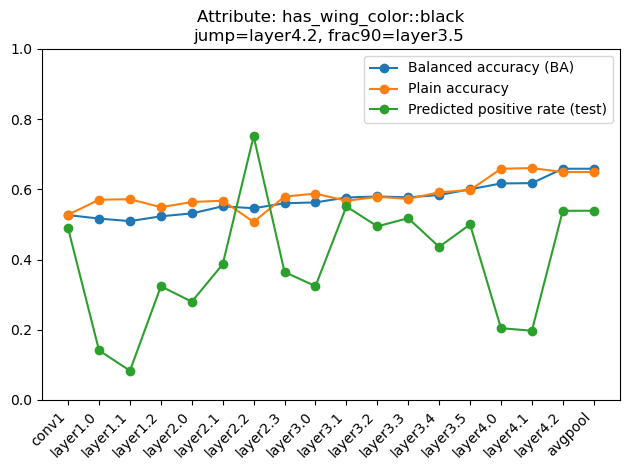

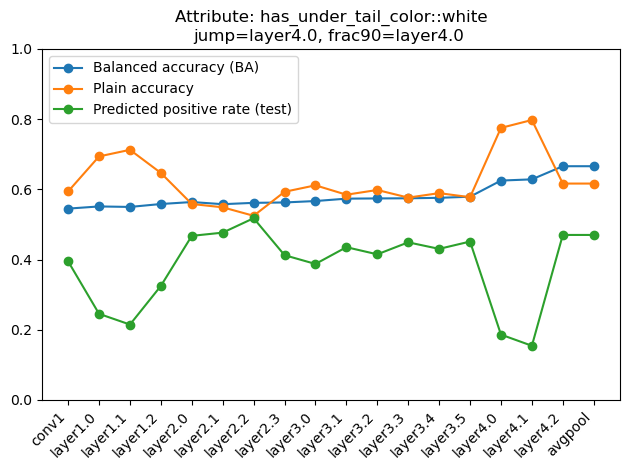

In [29]:
import matplotlib.pyplot as plt

def plot_attribute_curve(attr: str, title_extra="", device=None):
    """
    Mirrors lfcbm_newrecall.ipynb plot_concept_curve.
    Plots BA, plain accuracy, and predicted positive rate across LAYERS
    for a single CUB attribute, using a binary weighted linear probe.
    """
    aid   = attr_name_to_id[attr]
    lab   = build_attr_labeled_df(meta, img_attr_long, aid, min_certainty=1)
    lab_i = lab.set_index("image_id")
    ytr   = lab_i.loc[aligned_tr_ids, "y"].to_numpy(dtype=np.int32)
    yte   = lab_i.loc[aligned_te_ids, "y"].to_numpy(dtype=np.int32)

    ba_curve, acc_curve, ppos_curve = [], [], []
    for layer in LAYERS:
        ba, acc, ppos, _ = train_linear_probe_binary_weighted(
            aligned_base_tr[layer], ytr,
            aligned_base_te[layer], yte,
            epochs=8, seed=0, device=device,
        )
        ba_curve.append(ba); acc_curve.append(acc); ppos_curve.append(ppos)

    ba_curve = np.asarray(ba_curve, float)
    e_jump = sharp_rise_idx(ba_curve)
    e_frac = frac_of_final_idx(ba_curve, frac=0.90)

    plt.figure()
    plt.plot(ba_curve,   marker="o", label="Balanced accuracy (BA)")
    plt.plot(acc_curve,  marker="o", label="Plain accuracy")
    plt.plot(ppos_curve, marker="o", label="Predicted positive rate (test)")
    plt.xticks(range(len(LAYERS)), LAYERS, rotation=45, ha="right")
    plt.ylim(0, 1.0)
    plt.title(f"Attribute: {attr}\njump={LAYERS[e_jump]}, frac90={LAYERS[e_frac]} {title_extra}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# examples — first and last attribute in ATTR_LIST
plot_attribute_curve(ATTR_LIST[0])
plot_attribute_curve(ATTR_LIST[-1])


In [30]:
# ── Choose emergence criterion + tag pre / at / post ─────────────────────────
# Mirrors lfcbm_newrecall.ipynb Cell 28.
# "frac90": earliest layer reaching >= 90% of final accuracy (best for "when well-encoded")
# "sharp_jump": layer of the single largest accuracy jump (best for phase-transition analysis)

EMERGE_CRITERION = "sharp_jump"   # change to "sharp_jump" to switch
emerge_col = "emerge_idx_frac" if EMERGE_CRITERION == "frac90" else "emerge_idx_jump"
layer_col  = "emerge_layer_frac" if EMERGE_CRITERION == "frac90" else "emerge_layer_jump"

print(f"Species emergence layer (baseline): {LAYERS[species_emerge_idx_ba]}")
print()
for crit, col in [("frac90", "emerge_idx_frac"), ("sharp_jump", "emerge_idx_jump")]:
    at_   = attr_emerge_df[attr_emerge_df[col] == species_emerge_idx_ba]
    after = attr_emerge_df[attr_emerge_df[col] >  species_emerge_idx_ba]
    pre   = attr_emerge_df[attr_emerge_df[col] <  species_emerge_idx_ba]
    print(f"[{crit}]  PRE={len(pre)}  AT={len(at_)}  AFTER={len(after)}")

attr_emerge_df["group"] = "at"
attr_emerge_df.loc[attr_emerge_df[emerge_col] < species_emerge_idx_ba, "group"] = "pre"
attr_emerge_df.loc[attr_emerge_df[emerge_col] > species_emerge_idx_ba, "group"] = "post"

print(f"\nUsing criterion: {EMERGE_CRITERION}")
print("  pre:",  (attr_emerge_df["group"] == "pre").sum(),
      " at:",   (attr_emerge_df["group"] == "at").sum(),
      " post:", (attr_emerge_df["group"] == "post").sum())
print()
print(attr_emerge_df[["attr", layer_col, "group", "final_acc"]])

Species emergence layer (baseline): layer4.0

[frac90]  PRE=18  AT=29  AFTER=26
[sharp_jump]  PRE=18  AT=10  AFTER=45

Using criterion: sharp_jump
  pre: 18  at: 10  post: 45

                            attr emerge_layer_jump group  final_acc
0          has_wing_color::black          layer4.2  post   0.649292
1    has_bill_shape::all-purpose          layer4.2  post   0.692095
2      has_forehead_color::black          layer4.2  post   0.765792
3     has_upperparts_color::grey          layer4.2  post   0.497756
4    has_upperparts_color::black          layer4.2  post   0.653089
..                           ...               ...   ...        ...
68  has_upperparts_color::yellow          layer1.0   pre   0.847946
69    has_underparts_color::grey          layer4.2  post   0.400414
70        has_nape_color::yellow          layer1.0   pre   0.879876
71         has_back_color::white          layer4.2  post   0.712634
72   has_under_tail_color::white          layer4.0    at   0.616500

[73 row


[baseline] Attributes by emergence group:
group
post    45
pre     18
at      10
Name: count, dtype: int64

[baseline] Mean gap by emergence group:
           mean       std  count
group                           
at     0.293811  0.064633     10
post   0.230871  0.078449     45
pre    0.190472  0.097735     18


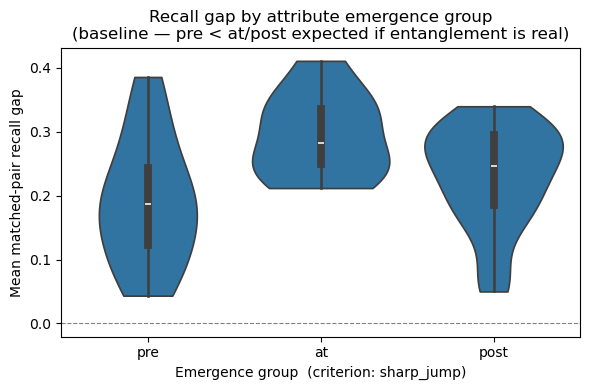

Saved: ../figures/recall_gap_by_group_baseline.pdf

[cbm] Attributes by emergence group:
group
post    45
pre     18
at      10
Name: count, dtype: int64

[cbm] Mean gap by emergence group:
           mean       std  count
group                           
at     0.258555  0.064908     10
post   0.221731  0.065962     45
pre    0.216345  0.069893     18


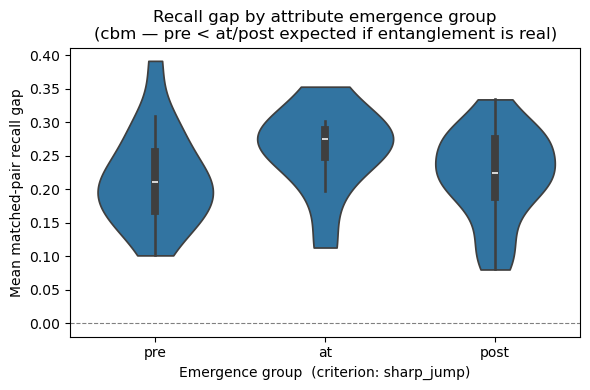

Saved: ../figures/recall_gap_by_group_cbm.pdf


In [31]:
# ── Group-comparison analysis: pre vs. at vs. post (baseline + CBM) ─────────
# Mirrors lfcbm_newrecall.ipynb Cell 53.
# Tests whether the recall gap is higher for attributes that emerge AFTER species identity.
# If yes in LF-CBM but NOT here: entanglement is specific to LF-CBM.
# If yes here too: entanglement is a property of the backbone, not the bottleneck.

import os
os.makedirs("../figures", exist_ok=True)

for model_name, info_df in [("baseline", baseline_info), ("cbm", cbm_info)]:
    if info_df.empty or "attr" not in info_df.columns:
        print(f"[{model_name}] info_df empty or missing 'attr' column; run run_many first")
        continue

    grp = info_df.merge(
        attr_emerge_df[["attr", "group", emerge_col, layer_col]],
        on="attr", how="left",
    )

    print(f"\n[{model_name}] Attributes by emergence group:")
    print(grp["group"].value_counts())
    print(f"\n[{model_name}] Mean gap by emergence group:")
    print(grp.groupby("group")["mean_gap"].agg(["mean", "std", "count"]))

    try:
        import matplotlib.pyplot as plt
        import seaborn as sns

        fig, ax = plt.subplots(figsize=(6, 4))
        order = [g for g in ["pre", "at", "post"] if g in grp["group"].values]
        sns.violinplot(data=grp, x="group", y="mean_gap",
                       order=order, inner="box", cut=0, ax=ax)
        ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
        ax.set_xlabel(f"Emergence group  (criterion: {EMERGE_CRITERION})")
        ax.set_ylabel("Mean matched-pair recall gap")
        ax.set_title(f"Recall gap by attribute emergence group\n"
                     f"({model_name} — pre < at/post expected if entanglement is real)")
        plt.tight_layout()
        fig_path = f"../figures/recall_gap_by_group_{model_name}.pdf"
        plt.savefig(fig_path, bbox_inches="tight")
        plt.show()
        print(f"Saved: {fig_path}")
    except Exception as e:
        print(f"Plot failed ({model_name}):", e)
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(6, 4))
        order = [g for g in ["pre", "at", "post"] if g in grp["group"].values]
        for g in order:
            vals = grp[grp["group"] == g]["mean_gap"].dropna().values
            ax.scatter([g] * len(vals), vals, alpha=0.6, label=g)
        ax.axhline(0, color="grey", linestyle="--")
        ax.set_ylabel("Mean matched-pair recall gap")
        ax.set_title(f"Recall gap by group ({model_name})")
        plt.tight_layout()
        plt.savefig(f"../figures/recall_gap_by_group_{model_name}.pdf", bbox_inches="tight")
        plt.show()

In [32]:
# ── Benjamini-Hochberg FDR correction on per-pair p-values ──────────────────
# Mirrors lfcbm_newrecall.ipynb Cell 54. Applied to both baseline and CBM pairs.

try:
    from statsmodels.stats.multitest import multipletests

    for name, df in [("baseline", baseline_pairs), ("cbm", cbm_pairs)]:
        if df.empty or "gap_p" not in df.columns:
            print(f"[{name}] No pairs data available for FDR correction")
            continue
        pvals              = df["gap_p"].fillna(1.0).to_numpy()
        reject, pvals_fdr, _, _ = multipletests(pvals, method="fdr_bh")
        df["gap_p_fdr"]    = pvals_fdr
        df["gap_sig_fdr"]  = reject
        n_sig = int(reject.sum())
        print(f"[{name}] FDR-corrected pairs (p < 0.05): {n_sig} / {len(df)}")

    print("Use gap_p_fdr < 0.05 as the significance threshold for reporting.")

except ImportError:
    print("statsmodels not available; install with: pip install statsmodels")
    print("Raw p-values in gap_p column (uncorrected for multiple testing)")

statsmodels not available; install with: pip install statsmodels
Raw p-values in gap_p column (uncorrected for multiple testing)


## Why the violin plot is the wrong view

The violin in cell 34 shows the **full distribution** of `mean_gap` for each emergence group. The professor's point: we do **not** expect every POST attribute to have a higher gap than every PRE attribute — most attributes in every group will have near-zero gaps simply because most attributes are not species-discriminating.

**What we actually expect** (if entanglement is real):
- The *proportion* of discriminative attributes should be higher in the POST group
- The right tail of the gap distribution should be heavier for POST
- There should be a positive trend between emergence layer index and gap magnitude

The three plots below test these questions directly — for both baseline ResNet and CBM.

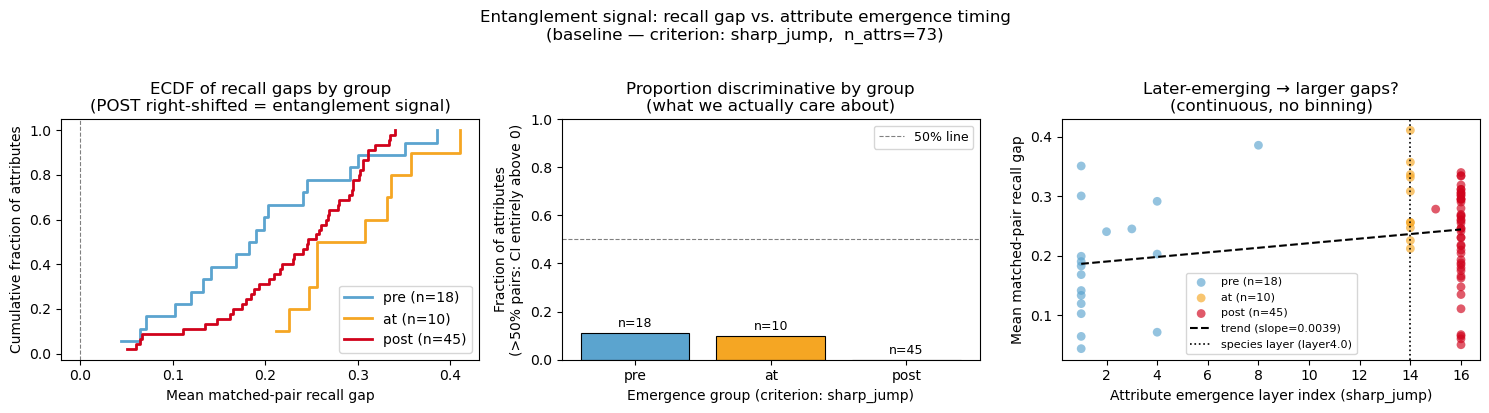

Saved: ../figures/recall_gap_entanglement_baseline.pdf


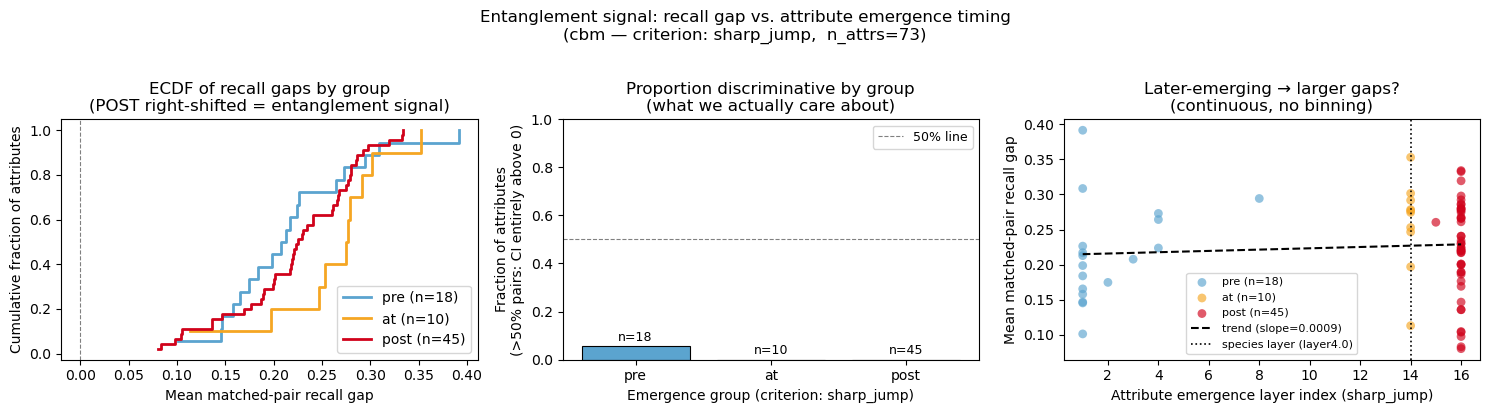

Saved: ../figures/recall_gap_entanglement_cbm.pdf


In [33]:
# ── Better visualization: what we actually expect to differ ─────────────────
# Mirrors lfcbm_newrecall.ipynb Cell 62, adapted for recall.ipynb:
#   - loops over both baseline and cbm models
#   - uses 'attr' column (not 'concept') and species_emerge_idx_ba
#   - merges summary (frac_ci_above0) with attr_emerge_df groups
#
# Three views per model:
#   1. ECDF of gap_mean by group — heavier right tail in POST = signal
#   2. % attributes with CI entirely above 0 by group — directional proportion test
#   3. Scatter: continuous emergence index vs. gap_mean with regression trend

import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("../figures", exist_ok=True)

# Merge summary (has frac_ci_above0) with emergence group labels from attr_emerge_df
_egrp = attr_emerge_df[["attr", "group", emerge_col]].drop_duplicates("attr")
summary_grp = summary.merge(_egrp, on="attr", how="left")

group_order  = [g for g in ["pre", "at", "post"] if g in summary_grp["group"].dropna().values]
group_colors = {"pre": "#5BA4CF", "at": "#F5A623", "post": "#D0021B"}

for model_name in ["baseline", "cbm"]:
    sg = summary_grp[summary_grp["model"] == model_name].copy()
    if sg.empty:
        print(f"[{model_name}] no summary rows — skipping")
        continue

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # ── Plot 1: ECDF of gap_mean by group ────────────────────────────────────
    ax = axes[0]
    for g in group_order:
        vals = sg[sg["group"] == g]["gap_mean"].dropna().values
        if len(vals) == 0:
            continue
        vals_s = np.sort(vals)
        ecdf   = np.arange(1, len(vals_s) + 1) / len(vals_s)
        ax.step(vals_s, ecdf, where="post", label=f"{g} (n={len(vals)})",
                color=group_colors.get(g), linewidth=2)
    ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Mean matched-pair recall gap")
    ax.set_ylabel("Cumulative fraction of attributes")
    ax.set_title("ECDF of recall gaps by group\n(POST right-shifted = entanglement signal)")
    ax.legend()

    # ── Plot 2: % attributes discriminative by group ──────────────────────────
    ax = axes[1]
    ci_col = "frac_ci_above0"
    if ci_col in sg.columns:
        disc_rows = []
        for g in group_order:
            sub = sg[sg["group"] == g][ci_col].dropna()
            if len(sub) == 0:
                continue
            disc_rows.append({"group": g, "frac_discriminative": float((sub > 0.5).mean()),
                               "n": len(sub)})
        disc_df = pd.DataFrame(disc_rows)
        bars = ax.bar(
            disc_df["group"], disc_df["frac_discriminative"],
            color=[group_colors.get(g, "grey") for g in disc_df["group"]],
            edgecolor="black", linewidth=0.8
        )
        for bar, row in zip(bars, disc_df.itertuples()):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01,
                    f"n={row.n}", ha="center", va="bottom", fontsize=9)
        ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, label="50% line")
        ax.set_ylim(0, 1)
        ax.set_xlabel(f"Emergence group (criterion: {EMERGE_CRITERION})")
        ax.set_ylabel("Fraction of attributes\n(>50% pairs: CI entirely above 0)")
        ax.set_title("Proportion discriminative by group\n(what we actually care about)")
        ax.legend(fontsize=9)
    else:
        ax.text(0.5, 0.5, "frac_ci_above0 not available\n(run summarize_by_attr first)",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_title("Proportion discriminative")

    # ── Plot 3: Scatter — continuous emergence index vs. gap_mean ─────────────
    ax = axes[2]
    if emerge_col in sg.columns:
        for g in group_order:
            sub = sg[sg["group"] == g].dropna(subset=["gap_mean", emerge_col])
            if len(sub) == 0:
                continue
            ax.scatter(sub[emerge_col], sub["gap_mean"],
                       label=f"{g} (n={len(sub)})",
                       color=group_colors.get(g), alpha=0.65, s=40, edgecolors="none")
        all_v = sg.dropna(subset=["gap_mean", emerge_col])
        if len(all_v) > 5:
            xs = all_v[emerge_col].values.astype(float)
            ys = all_v["gap_mean"].values
            m, b = np.polyfit(xs, ys, 1)
            xline = np.linspace(xs.min(), xs.max(), 100)
            ax.plot(xline, m * xline + b, color="black", linestyle="--",
                    linewidth=1.5, label=f"trend (slope={m:.4f})")
        ax.axvline(species_emerge_idx_ba, color="black", linestyle=":", linewidth=1.2,
                   label=f"species layer ({LAYERS[species_emerge_idx_ba]})")
        ax.set_xlabel(f"Attribute emergence layer index ({EMERGE_CRITERION})")
        ax.set_ylabel("Mean matched-pair recall gap")
        ax.set_title("Later-emerging → larger gaps?\n(continuous, no binning)")
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, f"Column '{emerge_col}' not in data",
                ha="center", va="center", transform=ax.transAxes)

    plt.suptitle(
        f"Entanglement signal: recall gap vs. attribute emergence timing\n"
        f"({model_name} — criterion: {EMERGE_CRITERION},  n_attrs={len(sg)})",
        fontsize=12, y=1.02
    )
    plt.tight_layout()
    fig_path = f"../figures/recall_gap_entanglement_{model_name}.pdf"
    plt.savefig(fig_path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fig_path}")

Column names: ['image', 'attr_label', 'bird_label']


'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/jessica-bader/SUB/resolve/6687681ee20f37b375b9ea8354e5841409fd5d7e/data/test-00014-of-00023.parquet
Retrying in 1s [Retry 1/5].
'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/jessica-bader/SUB/resolve/6687681ee20f37b375b9ea8354e5841409fd5d7e/data/test-00014-of-00023.parquet
Retrying in 1s [Retry 1/5].
'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/jessica-bader/SUB/resolve/6687681ee20f37b375b9ea8354e5841409fd5d7e/data/test-00014-of-00023.parquet
Retrying in 1s [Retry 1/5].



--- 33 unique changed_attr values ---
  0  (n=1050)
  1  (n=750)
  2  (n=350)
  3  (n=50)
  4  (n=1100)
  5  (n=850)
  6  (n=1200)
  7  (n=1600)
  8  (n=1400)
  9  (n=1300)
  10  (n=1650)
  11  (n=1500)
  12  (n=1600)
  13  (n=650)
  14  (n=1550)
  15  (n=1100)
  16  (n=1650)
  17  (n=650)
  18  (n=1650)
  19  (n=1400)
  20  (n=600)
  21  (n=1000)
  22  (n=1650)
  23  (n=1550)
  24  (n=1450)
  25  (n=1200)
  26  (n=1550)
  27  (n=200)
  28  (n=1050)
  29  (n=1100)
  30  (n=1400)
  31  (n=1000)
  32  (n=1600)

--- 33 unique bird values ---
  0  (n=1100)
  1  (n=1100)
  2  (n=850)
  3  (n=1300)
  4  (n=850)
  5  (n=1200)
  6  (n=1250)
  7  (n=1250)
  8  (n=1100)
  9  (n=1250)
  10  (n=1150)
  11  (n=1500)
  12  (n=1200)
  13  (n=1300)
  14  (n=1100)
  15  (n=1450)
  16  (n=950)
  17  (n=1050)
  18  (n=1250)
  19  (n=1200)
  20  (n=1200)
  21  (n=1350)
  22  (n=1300)
  23  (n=1200)
  24  (n=1350)
  25  (n=1150)
  26  (n=1100)
  27  (n=1200)
  28  (n=850)
  29  (n=1350)
  30  (n=1050)
  3

In [36]:
ds = load_dataset("jessica-bader/SUB", streaming=True, split="test")
print(ds.features)

{'image': Image(mode=None, decode=True), 'attr_label': ClassLabel(names=['has_back_color--grey', 'has_belly_pattern--striped', 'has_bill_color--grey', 'has_bill_shape--needle', 'has_breast_color--blue', 'has_breast_color--red', 'has_breast_color--white', 'has_breast_pattern--spotted', 'has_crown_color--black', 'has_crown_color--grey', 'has_crown_color--pink', 'has_crown_color--white', 'has_eye_color--blue', 'has_eye_color--white', 'has_eye_color--yellow', 'has_forehead_color--grey', 'has_leg_color--black', 'has_leg_color--grey', 'has_leg_color--pink', 'has_primary_color--blue', 'has_primary_color--brown', 'has_primary_color--green', 'has_primary_color--orange', 'has_tail_pattern--multi-colored', 'has_tail_pattern--solid', 'has_throat_color--blue', 'has_throat_color--yellow', 'has_underparts_color--green', 'has_underparts_color--red', 'has_upperparts_color--yellow', 'has_wing_color--black', 'has_wing_color--grey', 'has_wing_color--white']), 'bird_label': ClassLabel(names=['American_Gold